Excercise 1 Momentum Accelerated GD 

In [2]:

import autograd.numpy as np   

# import statment for gradient calculator
from autograd import grad  

from autograd import value_and_grad


# gradient descent function - inputs: g (input function), alpha (steplength parameter), max_its (maximum number of iterations), w (initialization)
def momentum_gradient_descent(g,alpha,max_its,w, b):
    # compute gradient module using autograd
    
    gradient = grad(g)
    d = -gradient(w)
    beta = b
    # run the gradient descent loop
    weight_history = [w]           # container for weight history
    cost_history = [g(w)]          # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_val = gradient(w)
        d = d*beta + (1 - beta)*(-grad_val)


        # take gradient descent step
        w = w + alpha*d
        
        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))
    final_grad = gradient(w)
    final_cost = g(w)
    return cost_history, np.array(weight_history)

In [19]:
C = np.array([[0.5,0],[0,9.75]])
g = lambda w: np.dot(np.dot(w.T,C),w)
alpha = 0.1
max_its = 25
w= np.array([10,1])
betas = [0, 0.1, 0.7]
results = {}

for b in betas :
    c_history, w_history = momentum_gradient_descent(g, alpha, max_its, w, b)
    results[b] = {
        'weights': w_history,
        'costs': c_history
    }

print(type(results[0]['weights']))
print(results[0]['weights'].shape)
print(results[0]['weights'][0])

<class 'numpy.ndarray'>
(26, 2)
[10.  1.]


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

<Figure size 800x600 with 0 Axes>

c:\Users\Rashawn\3LM3 Machine learning and neural networks\MLRPlotting\static_plotter.py:740: MatplotlibDeprecationWarning: 
The M attribute was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use self.axes.M instead.
  xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, renderer.M)


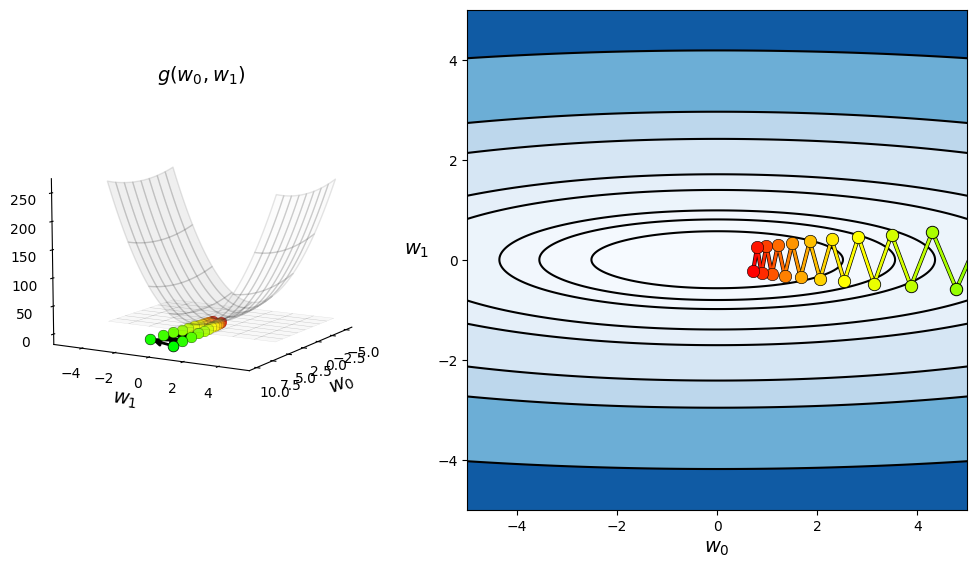

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

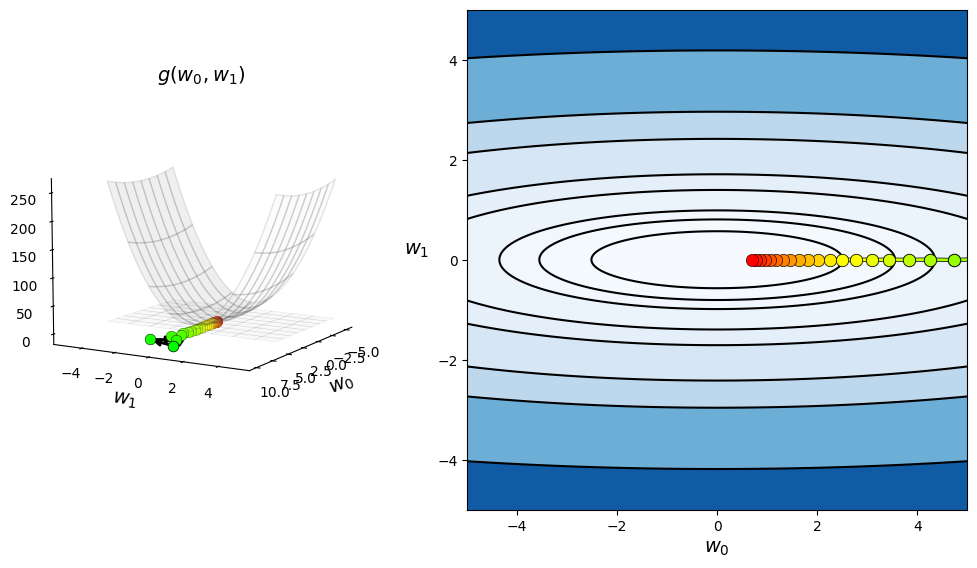

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

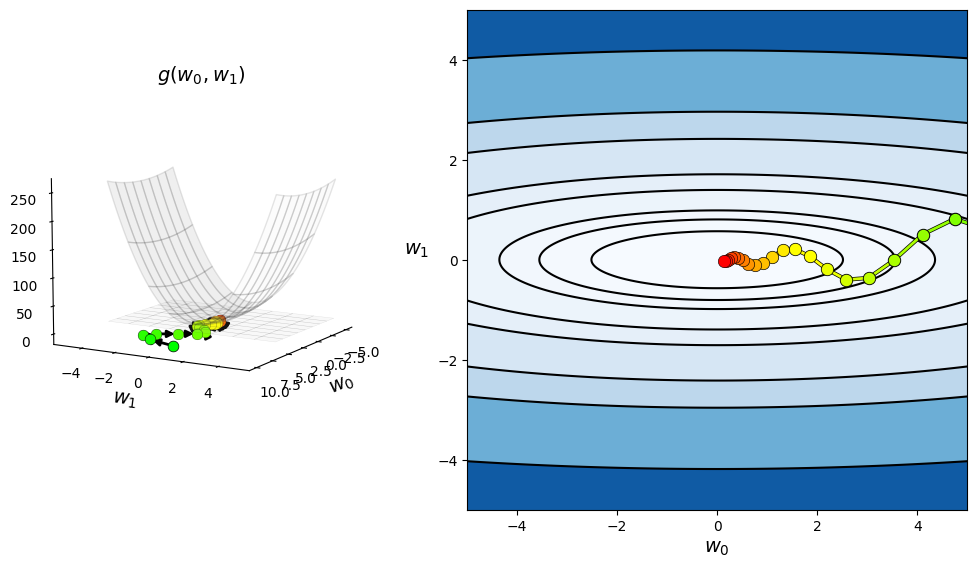

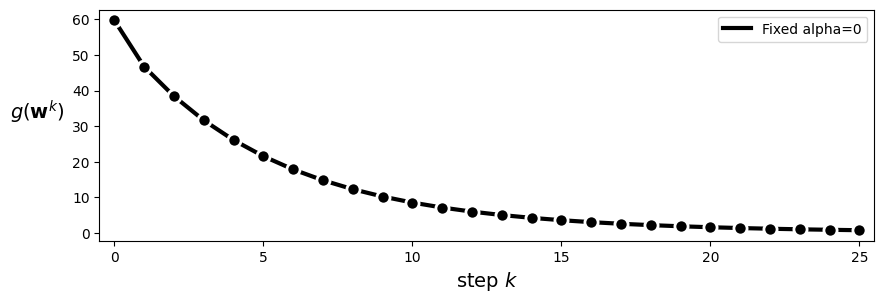

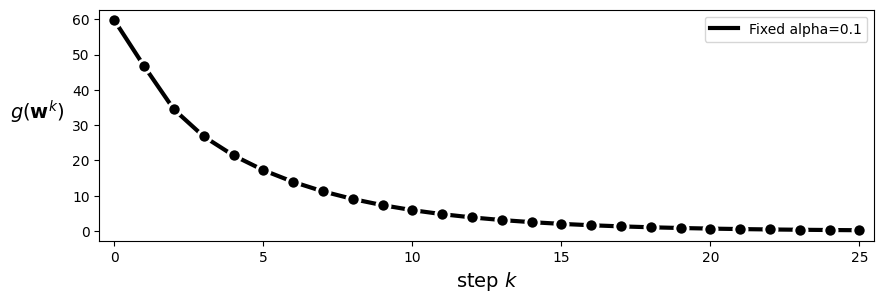

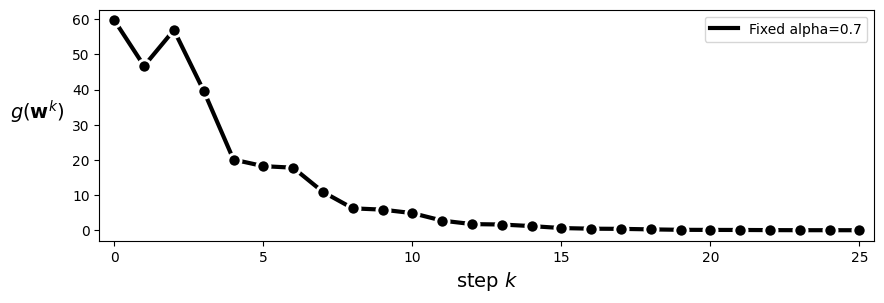

In [18]:
import sys
sys.path.append('C:\\Users\\Rashawn\\3LM3 Machine learning and neural networks\\MLRPlotting')
import matplotlib.pyplot as plt
from MLRPlotting import static_plotter

static_plotter = static_plotter.Visualizer();

C = np.array([[0.5,0],[0,9.75]])
g = lambda w: np.dot(np.dot(w.T,C),w)
alpha = 0.1
max_its = 25
w= np.array([10,1])
betas = [0, 0.1, 0.7]

results = {}

for b in betas :
    c_history, w_history = momentum_gradient_descent(g, alpha, max_its, w, b)
    results[b] = {
        'weights': w_history,
        'costs': c_history
    }

plt.figure(figsize=(8,6))

for b in betas :
    w_history = results[b]['weights']
    static_plotter.two_input_surface_contour_plot(g, w_history, view=[10,30], xmin = -5, xmax= 5, ymin = -5, ymax = 5, num_contours = 20)


for b in betas :    
    c_history = results[b]['costs']
    static_plotter.plot_cost_histories([c_history],start=(0),points=True,labels=[F'Fixed alpha={b}'])





In [58]:
# import automatic differentiator to compute gradient module
from autograd import grad 

# gradient descent function - inputs: g (input function), alpha (steplength parameter), max_its (maximum number of iterations), w (initialization)
def gradient_descent(g,alpha,max_its,w):
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w]           # container for weight history
    cost_history = [g(w)]          # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)
        print(f"step {k}: w={w}, grad={grad_eval} ")

        # take gradient descent step
        w = w - alpha*grad_eval
        if np.any(np.isnan(w)) :
            print('NAN value found')
            break
        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))
    
    return cost_history, weight_history

def normal_gradient_descent(g, alpha, max_its, w) :
    epsilon =  1e-8
    # compute gradient module using autograd
    gradient = grad(g)

    # run the gradient descent loop
    weight_history = [w]           # container for weight history
    cost_history = [g(w)]          # container for corresponding cost function history
    for k in range(max_its):
        # evaluate the gradient, store current weights and cost function value
        grad_eval = gradient(w)

        # take gradient descent step
        w = w - (alpha/ (np.linalg.norm(grad_eval) + epsilon)) * grad_eval 
        # record weight and cost
        weight_history.append(w)
        cost_history.append(g(w))
    
    return cost_history, weight_history

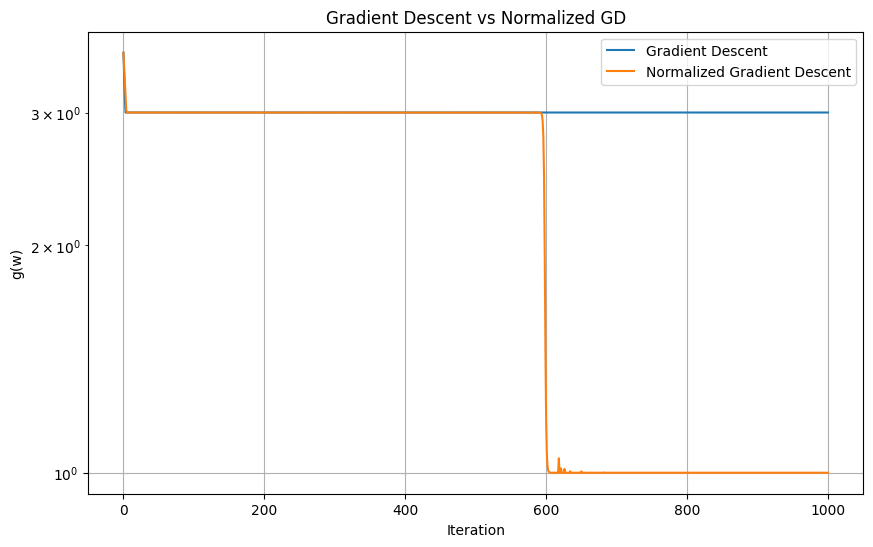

In [23]:
import sys
sys.path.append('C:\\Users\\Rashawn\\3LM3 Machine learning and neural networks\\MLRPlotting')
import matplotlib.pyplot as plt
from MLRPlotting import static_plotter

static_plotter = static_plotter.Visualizer();

g = lambda w: np.tanh(4*w[0] + 4*w[1]) + np.maximum(1, 0.4*w[0]**2) + 1
w = np.array([2.0,2.0])
alpha = 0.1
max_its = 1000

cost_history, w_history = gradient_descent(g, alpha, max_its, w)
cost_history_n = normal_gradient_descent(g, alpha, max_its, w)


plt.figure(figsize=(10,6))

plt.plot(cost_history, label='Gradient Descent')        
plt.plot(cost_history_n, label='Normalized Gradient Descent')

plt.xlabel('Iteration')
plt.ylabel('g(w)')
plt.yscale('log')
plt.title('Gradient Descent vs Normalized GD')
plt.legend()
plt.grid(True)
plt.show()







From the graph it becomes apparent the 'crawling' behaviour of standard gradient descent funcitons. becasue the value of alpha constant, it relies directly on the magnitude of the gradient. So if smaller gradient, then samller steps. in flatter regions this is where this kind of funciton struggles the most. The fully normalized gradient descent has a step length that is normalized, this means the step size stays ~ constant in relation to the gradient magnitude. This allows it to 'jump' across flat regions, and get out of plateaus.  

Exercise 3 Student Debt - Linear Regresssion using a single Newton Step

data y pred  (40, 1)
predicted student debt in 2050 = 3.93601194914973


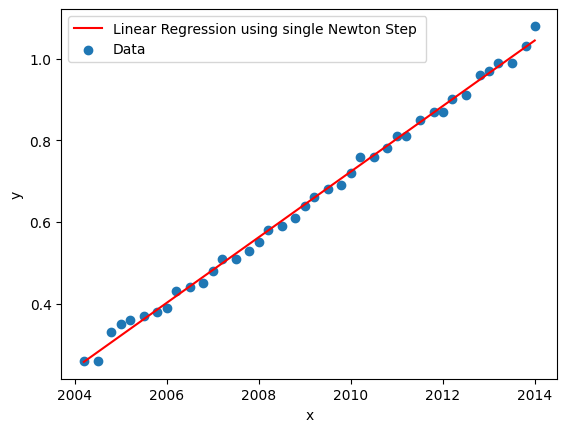

In [ ]:
import pandas as pd
# import the dataset
csvname = r"C:\Users\Rashawn\Downloads\student_debt_data.csv"
data = np.asarray(pd.read_csv(csvname,header = None))

# extract input
x = data[:,0]
x.shape = (len(x),1)
# pad input with ones
o = np.ones((len(x),1))
x_new = np.concatenate((o,x),axis = 1)

# extract input
y = data[:,1].reshape(-1,1)


A = x_new.T @ x_new
inv = np.linalg.pinv(A)
y_pred = x_new @ w
b = x_new.T @ y 
w = inv @ b

print(f"data y pred  {y_pred}")



x_future = 2050
x_future_new = np.array([1, x_future]).reshape(1,2)
y_future_pred = x_future_new @ w

print(F"predicted student debt in 2050 = {y_future_pred[0,0]}")

plt.scatter(x, y, label='Data')
plt.plot(x, y_pred, color='r', label='Linear Regression using single Newton Step ')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()




Exercise 4 Linear regression with optimization 

 these are the cost histories [63537.513033789815, 63087.59624156807, 62640.53256977554, 62196.31993825114, 61754.95623011587, 61316.439290933566, 60880.76692784851, 60447.936908699434, 60017.946961108944, 59590.79477154781, 59166.47798437312, 58744.994200839705, 58326.340978083725, 57910.51582807785, 57497.51621655688, 57087.339561913046, 56679.98323405981, 56275.444553263565, 55873.72078894174, 55474.80915842657, 55078.70682569334, 54685.41090005194, 54294.91843480065, 53907.226425840854, 53522.331810251475, 53140.23146482193, 52760.9222045421, 52384.40078104814, 52010.66388102267, 51639.70812454767, 51271.53006340906, 50906.12617935087, 50543.492882277846, 50183.626508404624, 49826.523318349835, 49472.17949517345, 49120.59114235548, 48771.7542817144, 48425.66485126312, 48082.31870300083, 47741.71160063852, 47403.83921725634, 47068.69713289058, 46736.28083204807, 46406.585701145974, 46079.60702587463, 45755.339988481166, 45433.7796649715, 45114.921022228504, 44798.75891504364, 44485.

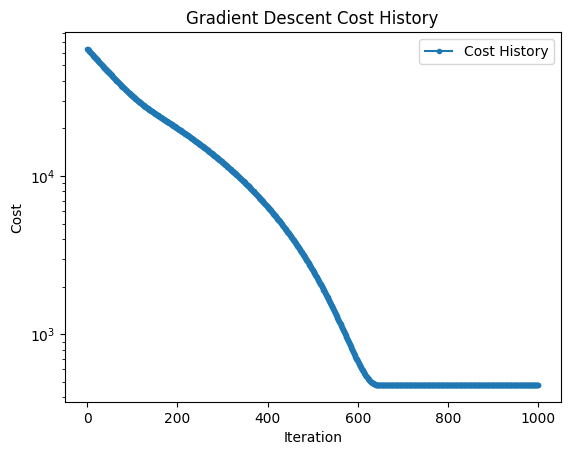

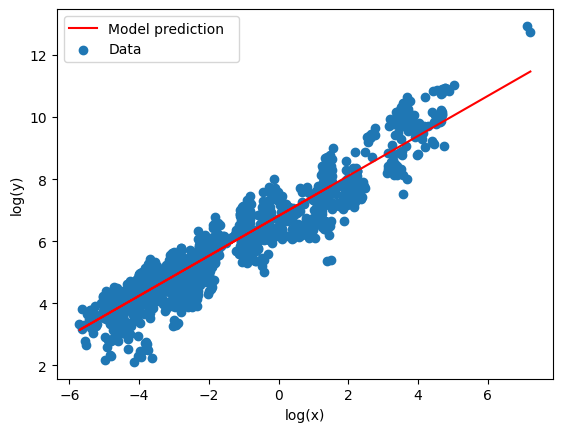

3.17214910669821


In [ ]:
csvname = r"C:\Users\Rashawn\Downloads\kleibers_law_data.csv"
data = np.asarray(pd.read_csv(csvname,header = None))

x = data[0, :]
y= data[1,]
alpha = 0.01
max_its = 1000

u = np.log(x)
z = np.log(y)

w_init = np.array([1.0,1.0])

def model(u,w) : 
    return w[0] + w[1] * u 

def least_squared(w) : 
    z_pred = model(u,w)
    return np.sum((z_pred - z)**2)


cost_history, w_history = normal_gradient_descent(least_squared, alpha, max_its, w_init)

w_final = w_history[-1]

z_pred = model(u, w_final)

plt.plot(cost_history, marker='o', markersize=3, label='Cost History')
plt.yscale('log')  # use log scale for large value range
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Gradient Descent Cost History')
plt.legend()
plt.show()


plt.scatter(u, z, label='Data')
plt.plot(u, z_pred, color='r', label='Model prediction  ')
plt.xlabel('log(x)')
plt.ylabel('log(y)')
plt.legend()
plt.show()

w_kg = 10
z_10kg = w_final[0]+ w_final[1] * w_kg
calories = z_10kg/4.18

print(f' Calories: {calories}')

